In [1]:
import numpy as np
from scipy.misc import face
from scipy.ndimage import zoom
from scipy.special import logsumexp
import torch

import deepgaze_pytorch
from deepgaze_pytorch import MSDBDataset

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

model = deepgaze_pytorch.DeepGazeMSDB(pretrained=True).to(DEVICE)

image = face()

# load precomputed centerbias log density (from MIT1003) over a 1024x1024 image
# you can download the centerbias from https://github.com/matthias-k/DeepGaze/releases/download/v1.0.0/centerbias_mit1003.npy
# alternatively, you can use a uniform centerbias via `centerbias_template = np.zeros((1024, 1024))`.
centerbias_template = np.load('../centerbias_mit1003.npy')
# rescale to match image size
centerbias = zoom(centerbias_template, (image.shape[0]/centerbias_template.shape[0], image.shape[1]/centerbias_template.shape[1]), order=0, mode='nearest')
# renormalize log density
centerbias -= logsumexp(centerbias)

def predict_log_density(image, centerbias):
    print(f"Predicting log density for image of shape {image.shape}")
    image_tensor = torch.tensor([image.transpose(2, 0, 1)]).to(DEVICE)
    centerbias_tensor = torch.tensor([centerbias]).to(DEVICE)

    # For a new/unknown dataset, use averaged parameters for generalization:
    log_density_prediction = model(image_tensor, centerbias_tensor, pixel_per_dva=35.0, dataset=None)
    return log_density_prediction

Using cache found in /u/b/chengn30/.cache/torch/hub/facebookresearch_dinov2_6a62615
/u/b/chengn30/.cache/torch/hub/facebookresearch_dinov2_6a62615/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/u/b/chengn30/.cache/torch/hub/facebookresearch_dinov2_6a62615/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/u/b/chengn30/.cache/torch/hub/facebookresearch_dinov2_6a62615/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
/tmp/ipykernel_2344397/2258322700.py:14: DeprecationWarning: scipy.misc.face has been deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. Dataset methods have moved into the scipy.datasets module. Use scipy.datasets.face instead.
  image = face()


In [6]:
import os

import matplotlib.pyplot as plt
from pysaliency.plotting import visualize_distribution

INPUT_PATH = 'inputs'
OUTPUT_PATH = 'outputs'

def visualize_prediction(image, log_density_prediction, log_path, heatmap_path):
    fig, ax = plt.subplots()
    ax.imshow(image)
    
    fig, ax = plt.subplots()
    ax.set_axis_off()
    ax.matshow(log_density_prediction.detach().cpu().numpy()[0])  # first image in batch
    plt.savefig(log_path)
    
    # f, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 3))
    # axs[0].imshow(image)
    # axs[0].set_axis_off()
    # axs[1].matshow(log_density_prediction.detach().cpu().numpy()[0])  # first image in batch
    # axs[1].set_axis_off()
    # visualize_distribution(log_density_prediction.detach().cpu().numpy()[0], ax=axs[2])
    # axs[2].set_axis_off()
    fig, ax = plt.subplots()
    ax.set_axis_off()
    visualize_distribution(log_density_prediction.detach().cpu().numpy()[0], ax=ax)
    plt.savefig(heatmap_path, bbox_inches='tight', pad_inches=0)

Predicting log density for image of shape (768, 1024, 3)
Predicting log density for image of shape (768, 1024, 3)


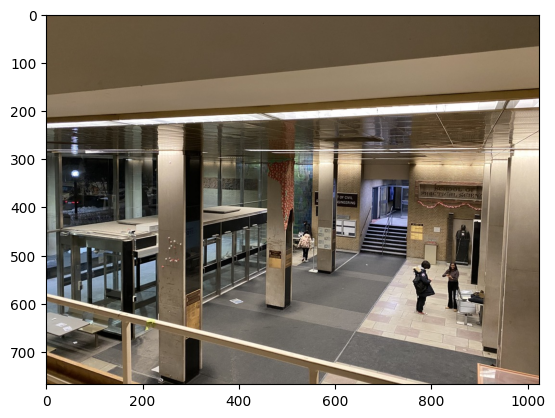

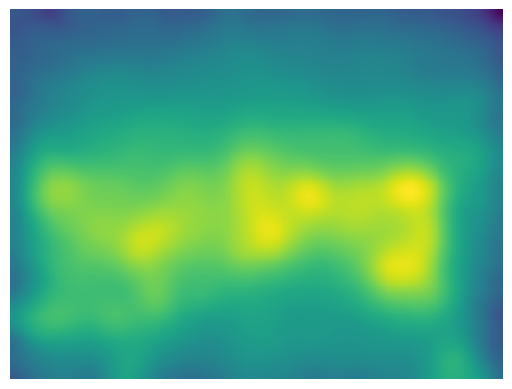

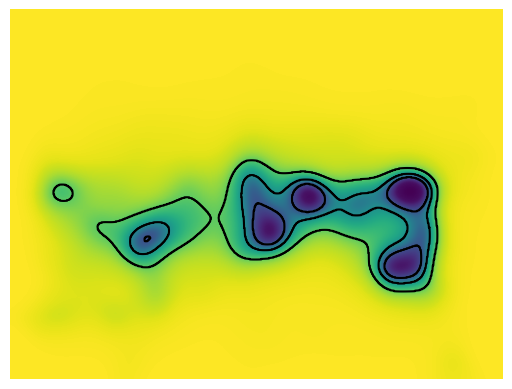

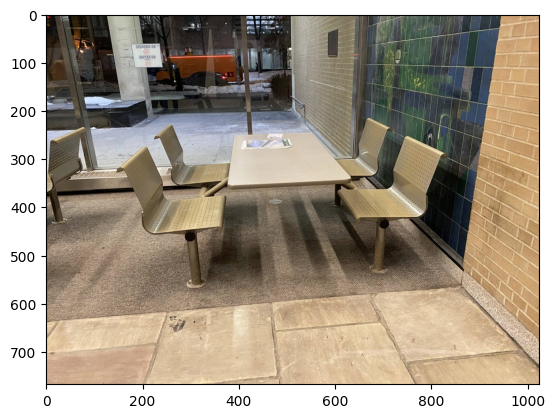

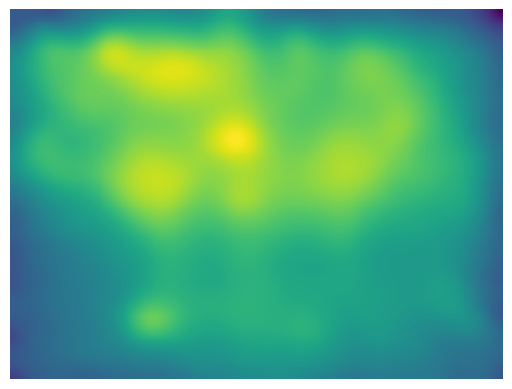

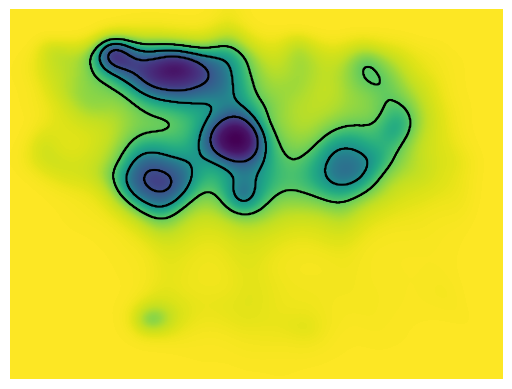

In [7]:
from PIL import Image
import numpy as np
import os
from pathlib import Path
from IPython.display import clear_output

INPUT_PATH = 'inputs'
input_batch_size = len(list(Path(INPUT_PATH).iterdir()))

OUTPUT_PATH = 'outputs'

for i in range(input_batch_size):
    file_path = os.path.join(INPUT_PATH, f'test_{i}.jpg')

    if os.path.exists(file_path):
        image = np.array(Image.open(file_path))
        
        # Make sure image is RGB (not RGBA)
        if image.shape[2] == 4:
            image = image[:, :, :3]
        
        log_density_prediction = predict_log_density(image, centerbias)
        log_path = os.path.join(OUTPUT_PATH, f'log-density/log_{i}.png')
        heatmap_path = os.path.join(OUTPUT_PATH, f'heatmaps/heat_{i}.png')
        visualize_prediction(image, log_density_prediction, log_path, heatmap_path)
    else:
        print(f"Error: The file '{file_path}' was not found.")